In [95]:
print("This is DNN assingnment 1")
# 1. Dataset Selection
import pandas as pd # for data manipulation (ek powerful library jo data handle karne ke liye use hoti hai)
df=pd.read_csv("adult.csv") #df=data frame jo bhi data read karna hai usko store karne ke liye use hota hai
df.head() #ye command data ke first 5 rows ko show karta hai
# df.info() #ye command data ke columns ke baare me information deta hai, jaise ki data types aur missing values

This is DNN assingnment 1


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [96]:
#DATA PREPROCESSING
# Remove missing values
df = df.dropna()
# Import encoder for converting text → numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()  # encoder object banaya

# Loop through all text (object) columns and convert them into numbers
for col in df.select_dtypes(include=['object']).columns:  
    df[col] = le.fit_transform(df[col])  # har text value ko numeric bana diya

# Separate features (X) and target (y)
X = df.drop("income", axis=1)  # income column hata diya → baaki sab input hai
y = df["income"]               # sirf income → output/target

# Split data into training and testing
from sklearn.model_selection import train_test_split

X_train, X_test , y_train, y_test = train_test_split(
    X, y, test_size=0.2)  # 80% training, 20% testing

# Import scaler to normalize data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # scaler object banaya

# Fit scaler on training data and transform it
X_train = scaler.fit_transform(X_train)  

# Apply same scaling on test data
X_test = scaler.transform(X_test)

In [108]:
# 3. Baseline Model (Logistic Regression from scratch)
import numpy as np  # for numerical calculations
class LogisticRegressionScratch:
    
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr              # learning rate (kitna fast seekhega)
        self.epochs = epochs      # kitni baar training chalegi
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))  # value ko 0-1 me convert karta hai
    
    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])  # sab weights 0 se start
        self.bias = 0                        # bias bhi 0
        self.loss_history = []               # loss track karne ke liye
        
        for i in range(self.epochs):
            
            # Step 1: Linear equation (z = wx + b)
            linear = np.dot(X, self.weights) + self.bias
            
            # Step 2: Sigmoid apply
            y_pred = self.sigmoid(linear)
            
            # Step 3: Loss calculate (error)
            #y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)  # avoid log(0)
            loss = -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))
            self.loss_history.append(loss)
            
            # Step 4: Gradients (kaise improve kare)
            dw = np.dot(X.T, (y_pred - y)) / len(y)
            db = np.mean(y_pred - y)
            
            # Step 5: Update weights
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    
    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear)
        return (y_pred > 0.5).astype(int)  # 0 ya 1 me convert

In [109]:
model1 = LogisticRegressionScratch()

model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

In [110]:
from sklearn.metrics import accuracy_score

print("Baseline Accuracy:", accuracy_score(y_test, pred1))

Baseline Accuracy: 0.8147200327566793


In [111]:
# 4. Multi-Layer Perceptron (MLP)
import numpy as np

class MLP:
    
    def __init__(self, input_size, hidden_size, output_size, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        
        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros(hidden_size)
        
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros(output_size)
        
        self.loss_history = []
    
    def relu(self, x):
        return np.maximum(0, x)  # ReLU activation
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))  # Sigmoid activation
    
    def fit(self, X, y):
        y = y.values.reshape(-1, 1)  # reshape target
        
        for i in range(self.epochs):
            
            # Forward propagation
            z1 = np.dot(X, self.W1) + self.b1
            a1 = self.relu(z1)
            
            z2 = np.dot(a1, self.W2) + self.b2
            y_pred = self.sigmoid(z2)
            
            # Compute loss
            #y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)  # avoid log(0)
            loss = -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))
            self.loss_history.append(loss)
            
            # Backpropagation
            dz2 = y_pred - y
            dW2 = np.dot(a1.T, dz2)
            db2 = np.sum(dz2)
            
            dz1 = np.dot(dz2, self.W2.T) * (z1 > 0)
            dW1 = np.dot(X.T, dz1)
            db1 = np.sum(dz1)
            
            # Update parameters
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
    
    def predict(self, X):
        a1 = self.relu(np.dot(X, self.W1) + self.b1)
        y_pred = self.sigmoid(np.dot(a1, self.W2) + self.b2)
        return (y_pred > 0.5).astype(int)

In [112]:
#Train MLP model
model2 = MLP(input_size=X_train.shape[1], hidden_size=10, output_size=1)

model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

C:\Users\hp\AppData\Local\Temp\ipykernel_15088\3364902376.py:39: RuntimeWarning: divide by zero encountered in log
  loss = -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))
C:\Users\hp\AppData\Local\Temp\ipykernel_15088\3364902376.py:39: RuntimeWarning: invalid value encountered in multiply
  loss = -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))
C:\Users\hp\AppData\Local\Temp\ipykernel_15088\3364902376.py:23: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))  # Sigmoid activation


In [113]:
#Check MLP accuracy
from sklearn.metrics import accuracy_score

print("MLP Accuracy:", accuracy_score(y_test, pred2))

MLP Accuracy: 0.2356433616542123


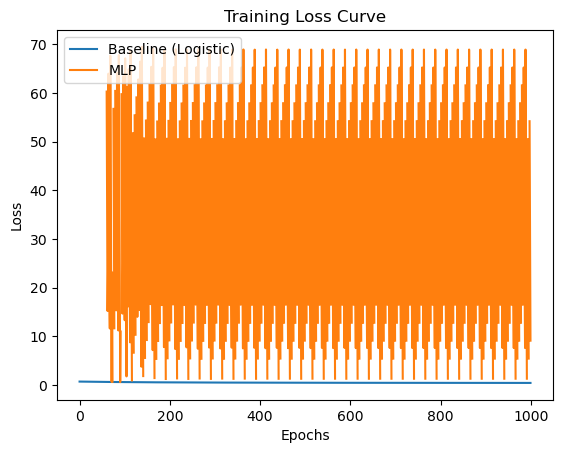

In [114]:
#Loss graph
# 5. Evaluation & Comparison
import matplotlib.pyplot as plt

# Plot loss for both models
plt.plot(model1.loss_history, label="Baseline (Logistic)")
plt.plot(model2.loss_history, label="MLP")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()

plt.show()



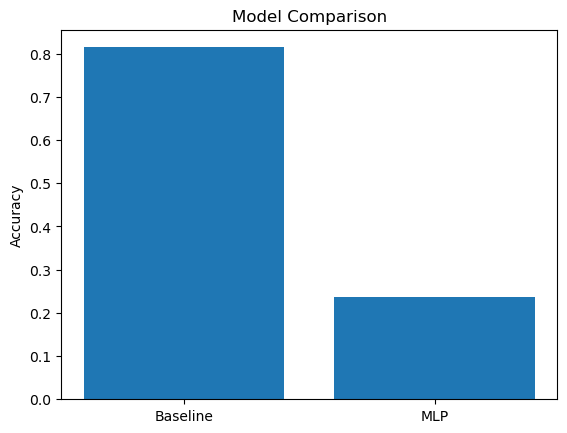

In [115]:
#Accuracy Comparison Bar Chart
baseline_acc = accuracy_score(y_test, pred1)
mlp_acc = accuracy_score(y_test, pred2)

models = ["Baseline", "MLP"]
accuracies = [baseline_acc, mlp_acc]

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

In [116]:
#ANALYSIS
#The baseline logistic regression model performed better than the MLP model. 
#This indicates that the dataset may have relatively simple relationships that can be captured by a linear model.
#The MLP model, although more powerful, may require better tuning of hyperparameters such as learning rate, number of hidden units, and number of epochs. 
#Additionally, MLP has higher computational cost due to multiple layers and backpropagation. 
#Both models showed decreasing loss, indicating successful training.

In [117]:
#get_assignment_results()
def get_assignment_results():
    return {
        "dataset_name": "Adult Income",
        "n_samples": len(df),
        "n_features": X.shape[1],
        "problem_type": "Binary Classification",
        "primary_metric": "Accuracy",
        "baseline_accuracy": baseline_acc,
        "mlp_accuracy": mlp_acc
    }

In [118]:
print(len(model1.loss_history))
print(len(model2.loss_history))

1000
1000
